In [2]:
#เชื่อม google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#ระบุที่อยู่ folder ของตัวเอง
%cd "/content/drive/MyDrive/Machine_Learning/KNN_Digit_Prediction"

/content/drive/MyDrive/Machine_Learning/KNN_Digit_Prediction


# **Data Science Life Cycle**

## **Business Understanding & Problem Definition**

**เป้าหมาย:** สร้างโมเดล K-Nearest Neighbors (KNN) เพื่อจำแนกตัวเลขลายมือ (digits) จากรูปภาพพิกเซล.

**ประเภทของปัญหา:** Classification (การจำแนกประเภท).

**Dataset:** MNIST Digits Dataset (จาก Scikit-learn).

**Baseline Model:** KNN.

## **Data Understanding & Data Collection**

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import seaborn as sn

In [5]:
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

## **Data Preprocessing & EDA**

In [6]:
X =digits.data
y =digits.target

In [7]:
X.shape

(1797, 64)

In [8]:
y.shape

(1797,)

In [9]:
n_samples, n_features = X.shape
print(f"Number of samples: {n_samples}")
print(f"Number of features (pixels per image): {n_features}")

Number of samples: 1797
Number of features (pixels per image): 64


In [10]:
n_classes = len(np.unique(y))
print(f"Number of classes: {n_classes}")
print(f"Unique target values: {np.unique(y)}")

Number of classes: 10
Unique target values: [0 1 2 3 4 5 6 7 8 9]


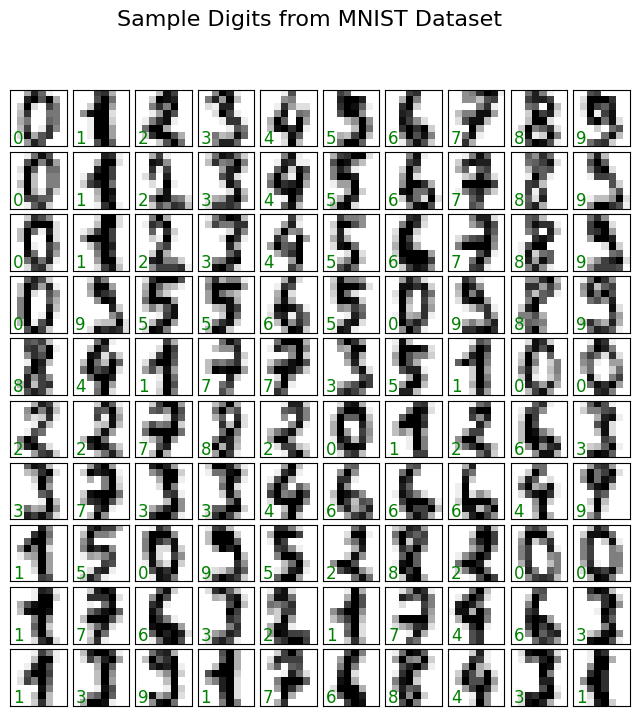

In [11]:
fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

# Flatten the axes array for easy iteration
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green', fontsize=12) # Display the target label

plt.suptitle("Sample Digits from MNIST Dataset", fontsize=16)
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Shape of X_scaled: {X_scaled.shape}")
print(f"Mean of first 5 features after scaling (should be close to 0): {X_scaled[:, :5].mean(axis=0)}")
print(f"Standard deviation of first 5 features after scaling (should be close to 1): {X_scaled[:, :5].std(axis=0)}")

Shape of X_scaled: (1797, 64)
Mean of first 5 features after scaling (should be close to 0): [ 0.00000000e+00 -2.56086502e-16 -2.34771702e-16 -3.05326777e-16
  1.39689163e-16]
Standard deviation of first 5 features after scaling (should be close to 1): [0. 1. 1. 1. 1.]


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Optional: Check class distribution in y_train and y_test
print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Shape of X_train: (1437, 64)
Shape of X_test: (360, 64)
Shape of y_train: (1437,)
Shape of y_test: (360,)

Class distribution in y_train:
0    0.098817
1    0.101601
2    0.098817
3    0.101601
4    0.100905
5    0.100905
6    0.100905
7    0.099513
8    0.096729
9    0.100209
Name: proportion, dtype: float64

Class distribution in y_test:
0    0.100000
1    0.100000
2    0.097222
3    0.102778
4    0.100000
5    0.102778
6    0.100000
7    0.100000
8    0.097222
9    0.100000
Name: proportion, dtype: float64


## **Model Training**

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_model =KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

## **Model Evaluation**

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
y_pred =knn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9666666666666667


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.97      1.00      0.99        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.91      0.94        35
           9       0.97      0.89      0.93        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [28]:
conf_matrix = confusion_matrix(y_test, y_pred)

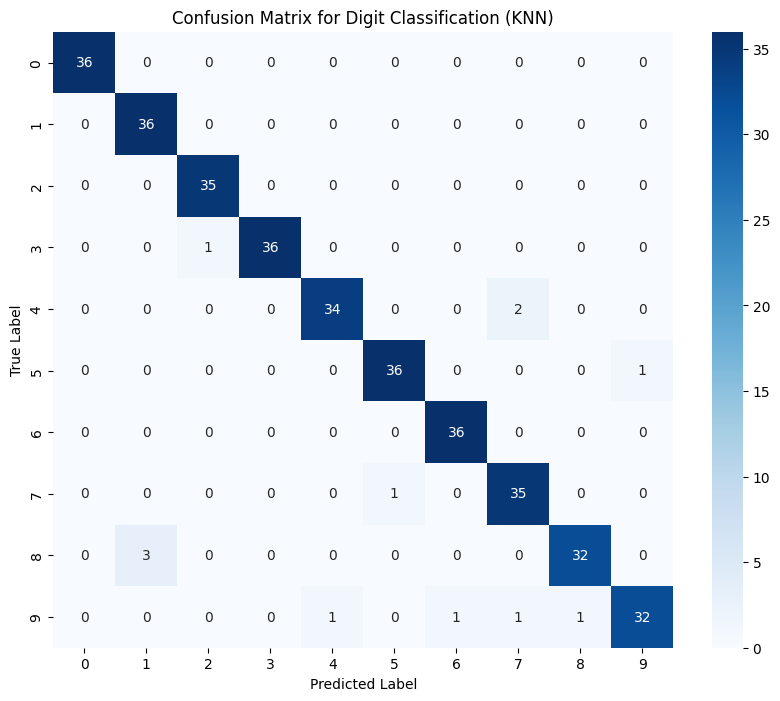

In [29]:
plt.figure(figsize=(10, 8)) # กำหนดขนาดของ Figure
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted Label') # Label แกน X
plt.ylabel('True Label') # Label แกน Y
plt.title('Confusion Matrix for Digit Classification (KNN)') # Title ของกราฟ
plt.show()

/tmp/ipython-input-31-3186777562.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


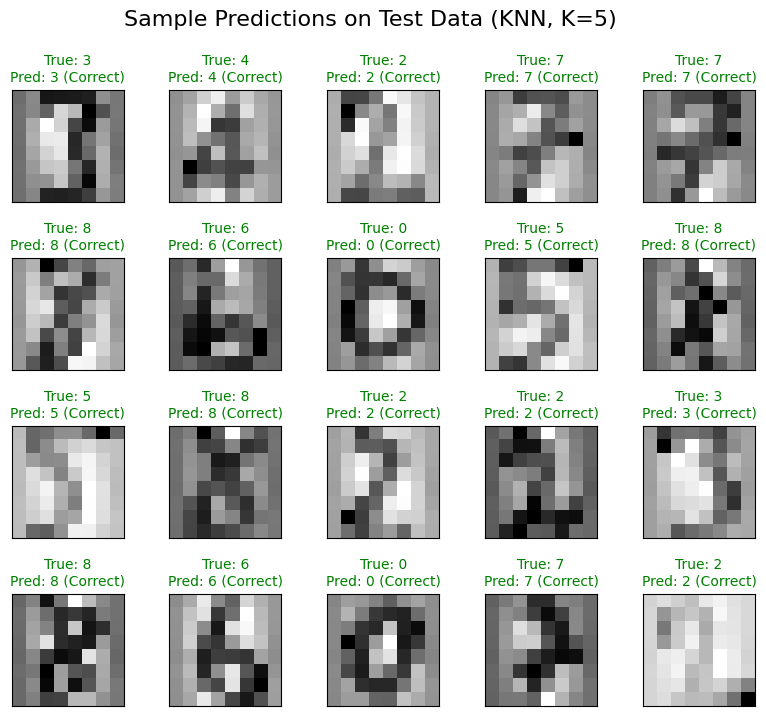

In [31]:
import numpy as np
import matplotlib.pyplot as plt

num_samples_to_show = 20
random_indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

fig, axes = plt.subplots(int(np.ceil(num_samples_to_show / 5)), 5, figsize=(10, 2 * int(np.ceil(num_samples_to_show / 5))),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.5, wspace=0.1))

for i, ax in enumerate(axes.flat):
    if i >= num_samples_to_show:
        ax.set_visible(False)
        continue

    idx = random_indices[i]
    image_to_display = X_test[idx].reshape(8, 8)
    ax.imshow(image_to_display, cmap='binary', interpolation='nearest')
    true_label = y_test[idx]
    predicted_label = y_pred[idx]

    if true_label == predicted_label:
        color = 'green'
        status = 'Correct'
    else:
        color = 'red'
        status = 'Incorrect'

    ax.set_title(f"True: {true_label}\nPred: {predicted_label} ({status})", color=color, fontsize=10)

plt.suptitle(f"Sample Predictions on Test Data (KNN, K=5)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()